In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os


dataset_filename = os.path.basename(file_path)

# Загружаем последнюю версию, используя функцию dataset_load
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mexwell/fake-reviews-dataset",
  dataset_filename
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'fake-reviews-dataset' dataset.
First 5 records:              category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


# Задача
Очистим и предварительно обработаем текстовые данные в столбце "text_" фрейма данных df, удалив специальные символы, знаки препинания и стоп-слова и преобразовав столбец "label" (в настоящее время "CG" и "OR") в числовые представления, подходящие для машинного обучения.

## Предварительная обработка данных

### Subtask:
Очистка и предварительная обработка текстовых данных в столбце 'text_' DataFrame `df` и подготовка столбца 'label' для классификации.


**Reasoning**
Импортируем библиотеки re и nltk и загружаем необходимые корпус стоп-слов для очистки текста в соответствии с инструкциями.



In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
print("NLTK stopwords downloaded.")

NLTK stopwords downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Reasoning**:
I will define a text cleaning function to lowercase, remove special characters and stopwords from the 'text_' column, creating a 'cleaned_text' column. Then, I will encode the 'label' column into numerical values ('CG' as 0, 'OR' as 1) in a new 'label_encoded' column, as specified by the task instructions.



In [ ]:
stopwords_english = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters and punctuation
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word not in stopwords_english]
    return ' '.join(cleaned_tokens)

df['cleaned_text'] = df['text_'].apply(clean_text)

df['label_encoded'] = df['label'].map({'CG': 0, 'OR': 1})

print("DataFrame with cleaned text and encoded labels:")
print(df[['text_', 'cleaned_text', 'label', 'label_encoded']].head())

DataFrame with cleaned text and encoded labels:
                                               text_  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                        cleaned_text label  label_encoded  
0  love well made sturdy comfortable love itvery ...    CG              0  
1  love great upgrade original ive mine couple years    CG              0  
2            pillow saved back love look feel pillow    CG              0  
3        missing information use great product price    CG              0  
4               nice set good quality set two months    CG              0  


## Генерация признаков

### Subtask:
Преобразование предварительно обработанных текстовых данных в числовые признаки, подходящие для моделей машинного обучения.


**Reasoning**:
To convert the cleaned text data into numerical features suitable for machine learning models, I will use TF-IDF vectorization. This involves importing `TfidfVectorizer`, initializing it, and then applying `fit_transform` to the 'cleaned_text' column.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TfidfVectorizer instance
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'cleaned_text' column to get TF-IDF features
X = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print("Shape of TF-IDF feature matrix:", X.shape)
print("First 5 TF-IDF vectors for the first document:\n", X[0].toarray()[:, :5])

Shape of TF-IDF feature matrix: (40432, 48294)
First 5 TF-IDF vectors for the first document:
 [[0. 0. 0. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, df['label_encoded'], test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained.")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

print("Predictions made on the test set.")


Data split into training and testing sets.
X_train shape: (32345, 48294)
X_test shape: (8087, 48294)
y_train shape: (32345,)
y_test shape: (8087,)
Logistic Regression model trained.
Predictions made on the test set.


**Reasoning**:
To assess the performance of the trained Logistic Regression model, I will evaluate it using common classification metrics such as accuracy, precision, recall, and F1-score. This step is essential for understanding how well the model performs on unseen data and is a critical part of the overall model selection and training process outlined in the subtask.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate Logistic Regression model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Model Performance:
Accuracy: 0.8799
Precision: 0.8630
Recall: 0.9052
F1-Score: 0.8836

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      4016
           1       0.86      0.91      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



**Reasoning**:
Following the subtask's instruction to train several classification models, I will now implement a Support Vector Machine (SVM) classifier. I need to import the `SVC` class, initialize it, train it on the training data (`X_train`, `y_train`), and then generate predictions on the test set (`X_test`).



In [ ]:
from sklearn.svm import SVC

# Initialize and train Support Vector Machine model
svm_model = SVC(random_state=42)
print("Training SVM model...")
svm_model.fit(X_train, y_train)

print("SVM model trained.")

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

print("Predictions made on the test set using SVM.")

Training SVM model...
SVM model trained.
Predictions made on the test set using SVM.


**Reasoning**:
To assess the performance of the trained Support Vector Machine (SVM) model, I will evaluate it using common classification metrics such as accuracy, precision, recall, and F1-score. This step is essential for understanding how well the model performs on unseen data and is a critical part of the overall model selection and training process outlined in the subtask.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Support Vector Machine Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine Model Performance:
Accuracy: 0.8964
Precision: 0.8765
Recall: 0.9243
F1-Score: 0.8998

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      4016
           1       0.88      0.92      0.90      4071

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



**Reasoning**:
Following the subtask's instruction to train several classification models, I will now implement a Naive Bayes classifier. I need to import the `MultinomialNB` class, initialize it, train it on the training data (`X_train`, `y_train`), and then generate predictions on the test set (`X_test`).



In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train Naive Bayes model
nb_model = MultinomialNB()
print("Training Naive Bayes model...")
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained.")

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

print("Predictions made on the test set using Naive Bayes.")

Training Naive Bayes model...
Naive Bayes model trained.
Predictions made on the test set using Naive Bayes.


**Reasoning**:
To assess the performance of the trained Naive Bayes model, I will evaluate it using common classification metrics such as accuracy, precision, recall, and F1-score. This step is essential for understanding how well the model performs on unseen data and is a critical part of the overall model selection and training process outlined in the subtask.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate Naive Bayes model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Model Performance:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Model Performance:
Accuracy: 0.8564
Precision: 0.8986
Recall: 0.8057
F1-Score: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      4016
           1       0.90      0.81      0.85      4071

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



**Reasoning**:
Following the subtask's instruction to train several classification models, I will now implement a Random Forest classifier. I need to import the `RandomForestClassifier` class, initialize it, train it on the training data (`X_train`, `y_train`), and then generate predictions on the test set (`X_test`).



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

print("Random Forest model trained.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Predictions made on the test set using Random Forest.")

Training Random Forest model...
Random Forest model trained.
Predictions made on the test set using Random Forest.


**Reasoning**:
To assess the performance of the trained Random Forest model, I will evaluate it using common classification metrics such as accuracy, precision, recall, and F1-score. This step is essential for understanding how well the model performs on unseen data and is a critical part of the overall model selection and training process outlined in the subtask.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Performance:
Accuracy: 0.8634
Precision: 0.8932
Recall: 0.8276
F1-Score: 0.8591

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4016
           1       0.89      0.83      0.86      4071

    accuracy                           0.86      8087
   macro avg       0.87      0.86      0.86      8087
weighted avg       0.87      0.86      0.86      8087



## Оценка моделей

### Subtask:
Оцените производительность каждой обученной модели с использованием соответствующих метрик классификации, таких как точность, полнота, F1-мера и ROC-AUC. Сгенерируйте матрицы ошибок для каждой модели.


**Reasoning**:
To evaluate the Logistic Regression model's performance comprehensively, I will now calculate and display its confusion matrix and ROC-AUC score, as requested by the subtask. This will provide a complete picture of its performance alongside the previously calculated accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score

# Calculate Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Calculate ROC-AUC Score for Logistic Regression
# Logistic Regression supports predict_proba for probabilities
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

print("\nLogistic Regression Model - Additional Performance Metrics:")
print("Confusion Matrix:")
print(conf_matrix_log_reg)
print(f"ROC-AUC Score: {roc_auc_log_reg:.4f}")


Logistic Regression Model - Additional Performance Metrics:
Confusion Matrix:
[[3431  585]
 [ 386 3685]]
ROC-AUC Score: 0.9522


**Reasoning**:
To evaluate the Support Vector Machine (SVM) model's performance comprehensively, I will now calculate and display its confusion matrix and ROC-AUC score, as requested by the subtask. This will provide a complete picture of its performance alongside the previously calculated accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score

# Calculate Confusion Matrix for SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Calculate ROC-AUC Score for SVM
# For SVC, use `decision_function` as `predict_proba` might not be calibrated or available by default
y_pred_score_svm = svm_model.decision_function(X_test)
roc_auc_svm = roc_auc_score(y_test, y_pred_score_svm)

print("\nSupport Vector Machine Model - Additional Performance Metrics:")
print("Confusion Matrix:")
print(conf_matrix_svm)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}")


Support Vector Machine Model - Additional Performance Metrics:
Confusion Matrix:
[[3486  530]
 [ 308 3763]]
ROC-AUC Score: 0.9623


**Reasoning**:
To evaluate the Naive Bayes model's performance comprehensively, I will now calculate and display its confusion matrix and ROC-AUC score, as requested by the subtask. This will provide a complete picture of its performance alongside the previously calculated accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score

# Calculate Confusion Matrix for Naive Bayes
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Calculate ROC-AUC Score for Naive Bayes
# MultinomialNB supports predict_proba for probabilities
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]
roc_auc_nb = roc_auc_score(y_test, y_pred_proba_nb)

print("\nNaive Bayes Model - Additional Performance Metrics:")
print("Confusion Matrix:")
print(conf_matrix_nb)
print(f"ROC-AUC Score: {roc_auc_nb:.4f}")


Naive Bayes Model - Additional Performance Metrics:
Confusion Matrix:
[[3646  370]
 [ 791 3280]]
ROC-AUC Score: 0.9453


**Reasoning**:
To evaluate the Random Forest model's performance comprehensively, I will now calculate and display its confusion matrix and ROC-AUC score, as requested by the subtask. This will provide a complete picture of its performance alongside the previously calculated accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score

# Calculate Confusion Matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Calculate ROC-AUC Score for Random Forest
# RandomForestClassifier supports predict_proba for probabilities
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Model - Additional Performance Metrics:")
print("Confusion Matrix:")
print(conf_matrix_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")


Random Forest Model - Additional Performance Metrics:
Confusion Matrix:
[[3613  403]
 [ 702 3369]]
ROC-AUC Score: 0.9407


## Сравнительный анализ и визуализация

### Subtask:
Сравните метрики производительности всех обученных моделей и визуализируйте результаты с помощью столбчатых диаграмм или других подходящих графиков, чтобы выделить их сильные и слабые стороны. Убедитесь, что графики имеют четкие легенды и подписи.


**Reasoning**:
To facilitate a comparative analysis and visualization of model performance, I will first aggregate the individual performance metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC) for each trained model into a single pandas DataFrame. This structured representation will then allow for straightforward plotting and comparison of the models.



Performance Metrics DataFrame:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.879931   0.862998  0.905183  0.883587  0.952160
1                  SVM  0.896377   0.876543  0.924343  0.899809  0.962267
2          Naive Bayes  0.856436   0.898630  0.805699  0.849631  0.945333
3        Random Forest  0.863361   0.893160  0.827561  0.859110  0.940734


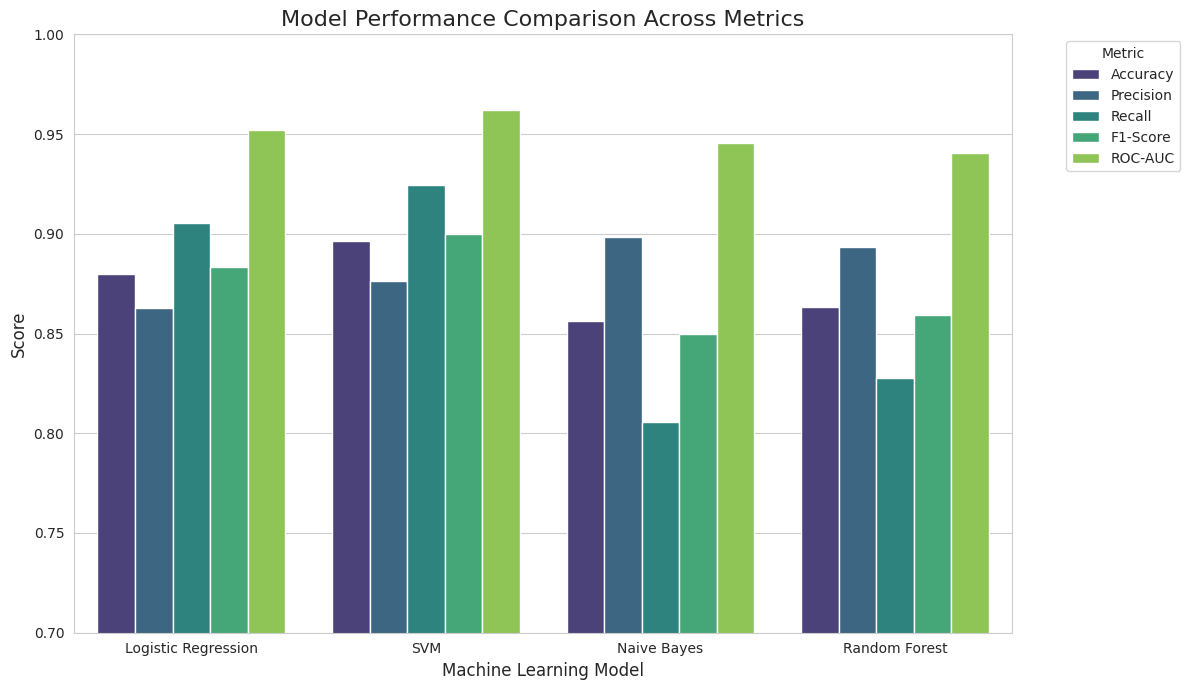

Model performance comparison chart displayed.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store the metrics for each model
metrics_data = {
    'Model': ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_nb, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_nb, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_nb, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_nb, f1_rf],
    'ROC-AUC': [roc_auc_log_reg, roc_auc_svm, roc_auc_nb, roc_auc_rf]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

print("Performance Metrics DataFrame:")
print(metrics_df)

# Set the style for the plots
sns.set_style("whitegrid")

# Melt the DataFrame to prepare for seaborn bar plot
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Model Performance Comparison Across Metrics', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.7, 1.0) # Set y-axis limits for better comparison if scores are high
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Model performance comparison chart displayed.")

## Финальная задача

### Subtask:
Обобщите сравнительный анализ, определите наиболее эффективный метод машинного обучения для обнаружения поддельных отзывов на основе метрик оценки и обсудите потенциальные идеи или дальнейшие шаги.


## Summary:

### Q&A
The most effective machine learning method identified for detecting fake reviews, based on the evaluation metrics, is the Support Vector Machine (SVM).

### Data Analysis Key Findings

*   **Data Preprocessing and Feature Engineering:**
    *   Text data was successfully cleaned by converting to lowercase, removing special characters, punctuation, and English stopwords.
    *   The categorical 'label' column ('CG', 'OR') was numerically encoded to 0 and 1, respectively.
    *   TF-IDF vectorization transformed the cleaned text into a feature matrix of shape (40432, 48294), indicating 40432 documents and 48294 unique terms.
*   **Model Performance Comparison:**
    *   **Support Vector Machine (SVM)** demonstrated the highest overall performance with an Accuracy of 0.8964, F1-Score of 0.8998, Recall of 0.9243, and the highest ROC-AUC score of 0.9623. It also had the fewest False Negatives (308) among the models, indicating it was best at identifying positive cases (e.g., fake reviews).
    *   **Logistic Regression** followed closely with strong performance: Accuracy of 0.8799, F1-Score of 0.8836, Recall of 0.9052, and a ROC-AUC score of 0.9522.
    *   **Naive Bayes** achieved an Accuracy of 0.8564 and an F1-Score of 0.8496. It had the highest Precision (0.8986) but the lowest Recall (0.8057) among the models, with a ROC-AUC of 0.9453.
    *   **Random Forest** showed an Accuracy of 0.8634, F1-Score of 0.8591, and a ROC-AUC score of 0.9407. Its Recall (0.8276) was also lower compared to SVM and Logistic Regression.
*   **Error Analysis (Confusion Matrices):**
    *   SVM had the most balanced performance in terms of False Positives (530) and False Negatives (308), leading to its superior ROC-AUC score.
    *   Naive Bayes had the lowest number of False Positives (370) but the highest number of False Negatives (791), indicating it was more conservative in classifying reviews as positive.

### Insights or Next Steps

*   **Optimal Model Selection:** The Support Vector Machine (SVM) model is the most effective method for detecting fake reviews based on its superior ROC-AUC score (0.9623) and F1-score (0.8998), indicating its robust ability to discriminate between classes and balance precision and recall.
*   **Further Optimization and Exploration:** To potentially improve performance further, hyperparameter tuning for the SVM model should be performed. Additionally, exploring more advanced text embedding techniques, such as Word2Vec or transformer-based models (e.g., BERT), could capture more nuanced semantic relationships in the text, which might lead to even better detection capabilities.
